In [ ]:
import pandas as pd
import numpy as mp
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# !pip install ydata_profiling


In [ ]:
# from ydata_profiling import ProfileReport
# profile=ProfileReport(data,title='Profiling Report',explorative=True)
# profile.to_file('output.html')



In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data.shape

(7043, 21)

In [ ]:
data['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
data=data.drop(['customerID','SeniorCitizen','PhoneService'],axis=1)

In [ ]:
data.shape

(7043, 18)

In [ ]:
data.head()

,gender,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,Yes,No,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,34,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data.duplicated().sum()

np.int64(26)

In [ ]:
data=data.drop_duplicates()

In [ ]:
data['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3088
DSL,2417
No,1512


In [ ]:
from  sklearn.preprocessing import OneHotEncoder
oh=OneHotEncoder()
data=pd.get_dummies(data, columns=['InternetService','Contract','PaymentMethod'],dtype=int)





In [ ]:
data.head()

,gender,Partner,Dependents,tenure,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,Female,Yes,No,1,No phone service,No,Yes,No,No,No,...,1,0,0,1,0,0,0,0,1,0
1,Male,No,No,34,No,Yes,No,Yes,No,No,...,1,0,0,0,1,0,0,0,0,1
2,Male,No,No,2,No,Yes,Yes,No,No,No,...,1,0,0,1,0,0,0,0,0,1
3,Male,No,No,45,No phone service,Yes,No,Yes,Yes,No,...,1,0,0,0,1,0,1,0,0,0
4,Female,No,No,2,No,No,No,No,No,No,...,0,1,0,1,0,0,0,0,1,0


In [ ]:
print(data['Partner'].unique())
print(data['Dependents'].unique())
print(data['PaperlessBilling'].unique())
print(data['Churn'].unique())

['Yes' 'No']
['No' 'Yes']
['Yes' 'No']
['No' 'Yes']


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7017 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7017 non-null   object 
 1   Partner                                  7017 non-null   object 
 2   Dependents                               7017 non-null   object 
 3   tenure                                   7017 non-null   int64  
 4   MultipleLines                            7017 non-null   object 
 5   OnlineSecurity                           7017 non-null   object 
 6   OnlineBackup                             7017 non-null   object 
 7   DeviceProtection                         7017 non-null   object 
 8   TechSupport                              7017 non-null   object 
 9   StreamingTV                              7017 non-null   object 
 10  StreamingMovies                          7017 non-nul

In [ ]:
data['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [ ]:
data['TotalCharges'] = data['TotalCharges'].replace(' ', 0).astype(float)

In [ ]:
data['TotalCharges'].dtype

dtype('float64')

In [ ]:
from  sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in data.columns:
   if data[col].dtype==object:
       data[col]=le.fit_transform(data[col])


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7017 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7017 non-null   int64  
 1   Partner                                  7017 non-null   int64  
 2   Dependents                               7017 non-null   int64  
 3   tenure                                   7017 non-null   int64  
 4   MultipleLines                            7017 non-null   int64  
 5   OnlineSecurity                           7017 non-null   int64  
 6   OnlineBackup                             7017 non-null   int64  
 7   DeviceProtection                         7017 non-null   int64  
 8   TechSupport                              7017 non-null   int64  
 9   StreamingTV                              7017 non-null   int64  
 10  StreamingMovies                          7017 non-nul

In [ ]:
data.head()

,gender,Partner,Dependents,tenure,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,0,2,0,0,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,34,0,2,0,2,0,0,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,2,0,2,2,0,0,0,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,45,1,2,0,2,2,0,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,2,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0


In [ ]:
y=data['Churn']
x=data.drop('Churn',axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
x_train

array([[ 0.9948467 ,  1.0280065 ,  1.52164924, ...,  1.90958717,
        -0.70653996, -0.54653847],
       [-1.00517999,  1.0280065 ,  1.52164924, ..., -0.5236734 ,
        -0.70653996,  1.82969735],
       [-1.00517999,  1.0280065 , -0.65718168, ..., -0.5236734 ,
        -0.70653996, -0.54653847],
       ...,
       [ 0.9948467 ,  1.0280065 ,  1.52164924, ...,  1.90958717,
        -0.70653996, -0.54653847],
       [-1.00517999,  1.0280065 ,  1.52164924, ..., -0.5236734 ,
         1.41534811, -0.54653847],
       [ 0.9948467 , -0.9727565 , -0.65718168, ...,  1.90958717,
        -0.70653996, -0.54653847]])

In [ ]:
x_test

array([[ 0.9948467 ,  1.0280065 ,  1.52164924, ..., -0.5236734 ,
        -0.70653996,  1.82969735],
       [-1.00517999, -0.9727565 , -0.65718168, ..., -0.5236734 ,
         1.41534811, -0.54653847],
       [ 0.9948467 , -0.9727565 , -0.65718168, ..., -0.5236734 ,
         1.41534811, -0.54653847],
       ...,
       [-1.00517999, -0.9727565 ,  1.52164924, ..., -0.5236734 ,
         1.41534811, -0.54653847],
       [ 0.9948467 ,  1.0280065 , -0.65718168, ...,  1.90958717,
        -0.70653996, -0.54653847],
       [-1.00517999, -0.9727565 , -0.65718168, ..., -0.5236734 ,
        -0.70653996,  1.82969735]])

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
sm=SMOTE()
x_train,y_train=sm.fit_resample(x_train,y_train)

In [ ]:
x_train.shape

(8214, 24)

In [ ]:
y_test=y_test.to_numpy()

In [ ]:
import tensorflow as tf
import keras
from keras.layers import Dense
from keras.models import Sequential
from keras.layers import Dropout


In [ ]:
model=Sequential()
model.add(Dense(40,activation='relu',input_dim=x_train.shape[1],kernel_initializer='he_normal'))
model.add(Dropout(0.3))
model.add(Dense(20,activation='relu',kernel_initializer='he_normal'))
model.add(Dropout(0.2))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_169 (Dense)               │ (None, 40)             │         1,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_81 (Dropout)            │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_170 (Dense)               │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_82 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_171 (Dense)               │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_83 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_172 (Dense)               │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,041 (7.97 KB)

 Trainable params: 2,041 (7.97 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy', optimizer=keras.optimizers.Adam(learning_rate=0.0006),metrics=['accuracy'])

In [ ]:
from keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [ ]:
history=model.fit(x_train,y_train,epochs=30,validation_split=0.2,callbacks=[early_stopping])

Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6316 - loss: 0.6183 - val_accuracy: 0.3932 - val_loss: 0.7765
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7077 - loss: 0.5394 - val_accuracy: 0.6299 - val_loss: 0.6610
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7349 - loss: 0.5148 - val_accuracy: 0.6817 - val_loss: 0.6309
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7414 - loss: 0.5071 - val_accuracy: 0.6999 - val_loss: 0.6237
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7539 - loss: 0.4979 - val_accuracy: 0.7304 - val_loss: 0.5962
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7576 - loss: 0.4940 - val_accuracy: 0.7103 - val_loss: 0.6239
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7573 - loss: 0.4885 - val_accuracy: 0.7115 - val_loss: 0.6304
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7661 - loss: 0.4848 - val_accuracy: 0.

In [ ]:
y_pred=model.predict(x_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step


Text(0.5, 0, 'Epoch')

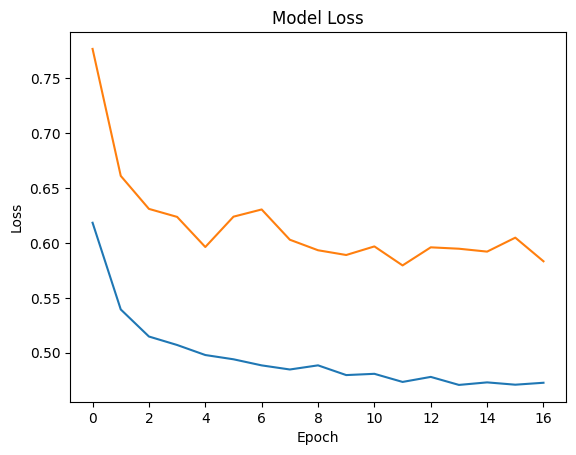

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

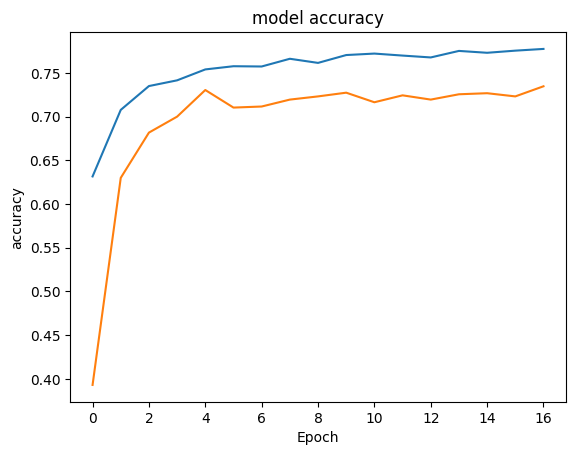

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')

In [ ]:
from sklearn.metrics import classification_report

y_pred_classes = (y_pred > 0.5).astype("int32")

# Step 3: Print out the final evaluation report
print("=================== CLASSIFICATION REPORT ===================")
print(classification_report(y_test, y_pred_classes))


=================== CLASSIFICATION REPORT ===================
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1056
           1       0.55      0.70      0.62       348

    accuracy                           0.78      1404
   macro avg       0.72      0.76      0.73      1404
weighted avg       0.81      0.78      0.79      1404

